![hslu_logo.png](img/hslu_logo.png)

## Week 6

<hr style="border:1px solid black">


# Exercise 2: MNIST Optimization with EAS
---
---
This excercise illustrates how to use the EAS environment by walking through the MNIST Usecase for a joint optimization of Accuracy and # of MAC operations.

### Use Case and Optimization Criteria

At the top of the configuration file [config.py](./config.py) we select the usecase and the optimization criteria:

     USECASE = "MNIST" 
     optim_metric = "macs_and_acc" 

### Initial DNA 0 training

Then we train the reference architecture (DNA 0) with the default training parameters in order to obtain a point of reference for the classification accuracy that the given network architecture can achieve. For this, in [config.py](./config.py) set:

     pop_size          = 1 
     nbr_of_evo_rounds = 0 

This will skip the evolution part of EAS.

Then, we start EAS:

In [1]:
%run -m main_evo

Running EA... Press Ctrl+C to exit.
Device list for tensorflow:
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 434637919511360877
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 46473413376
locality {
  bus_id: 1
}
incarnation: 15594028618429804354
physical_device_desc: "device: 0, name: DML, pci bus id: <undefined>"
xla_global_id: -1
]
Could no copy logs
-------------------------------------------------------
2025-03-30 20:14:36
-------------------------------------------------------
Maximum MACs allowed: 60000.0 - Maximum parameters allowed: 30000.0
x_train shape: (30000, 32, 32, 3, 1)
30000 train samples
Balance:  {0: 3007, 1: 2950, 2: 3004, 3: 3021, 4: 3035, 5: 2984, 6: 2984, 7: 2989, 8: 3004, 9: 3022}
3000 val samples
Balance:  {0: 288, 1: 314, 2: 307, 3: 288, 4: 288, 5: 308, 6: 311, 7: 308, 8: 281, 9: 307}
10000 test samples
Balance:  {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8:

With the defaul training parameters, the validation accuracy should be in the range of 94 to 96 %.

Next, we verify the quality of the training parameter set by evaluating the trained DNA 0 model on the test dataset by running

In [3]:
%run -m evaluate_model best_model_dna_0

Evaluating model: best_model_dna_0
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 activation (Activation)     (None, 26, 26, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 activation_1 (Activation)   (None, 11, 11, 64)        0         
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                 

If the testset accuracy is considerably lower that the evaluation accuracy achieved during training, the training parameters should be adjusted accordingly. A huge impact will have the **size of the trainings dataset**, both on accuracy and on overall runtime of EAS!!

Once a reasonable set of training parameters has been found, we can set the evolution parameters in consideration of the training run time of DNA 0. Here, for demonstration purposes we can use:

     pop_size                   = 4 
     nbr_of_evo_rounds          = 3 
     nbr_of_parents             = 1 
     nbr_of_children_per_parent = 2 

### Search Space Constraints

The next step is to fix the search space constraints in [config.py](./config.py). 

The search space is statically constrained with respect to the **maximum number of MACs and trainable parameters** allowed. Every new mutation (both during initialization and evolution) is dismissed if it does not satisfy these constraints. For the MNIST example, reasonable values could be:

     max_mac   = 3.5*10**6 
     max_param = 0.1*10**6 

The search space **limitation with respect to accuracy** is considered during re-insertion of new DNA's into the population at the end of every evolution round. The limit can be dynamically changed during evolution. For instance, with the following parameters the intial accuracy limit of 90 % is increased at the end ov every evolution round by 1 %. 

     acc_lim_init       = 0.9 
     acc_lim_step_time  = 1 
     acc_lim_step_hight = 0.01 

### 2D Ranking Function

Now we are going to define the 2D ranking function parameters. This is important, in order to optimally guide the evolutionary search into the desired direction.

The default 2D Gaussian function parameters for usecase MNIST in [config.py](./config.py) are:

     mu_acc    = 99        
     sigma_acc = 3.5       
     mu_mac    = 0.3*10**6  
     sigma_mac = 1.4*10**6  

Lets assume, we found that DNA 0 has an accuracy of 94.9 %, and we know that the # of MACs in DNA 0 is 2'440'960. If we target an optimized DNA with accuracy of 99 % and only 300'000 MACs, we could verify the 2D Gaussian parameters by producing a contour plot of the search space as follows:

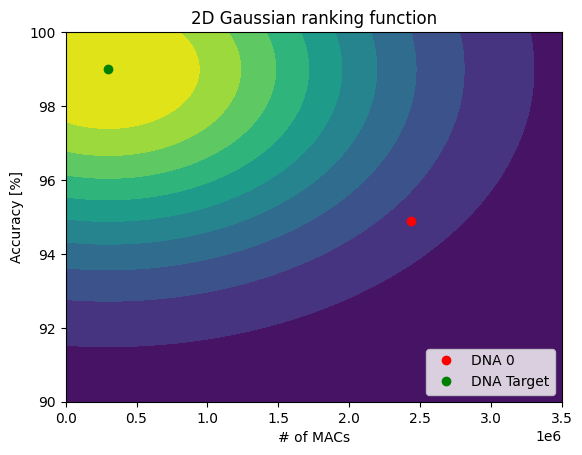

In [4]:
%run -m plot_rank_func 2440000 94.9 300000 99

In this case, the 2D Gaussian parameters are set reasonably, because the gradient in both x- and y-direction is such that any mutation from DNA 0 should be ranked higher the closer it comes to the target DNA.

On the other hand, if we would target a DNA with 100 % accurcy and allow 1'500'000 MACs, the 2D Gaussian function parameters would need to be adjusted, as can be seen with

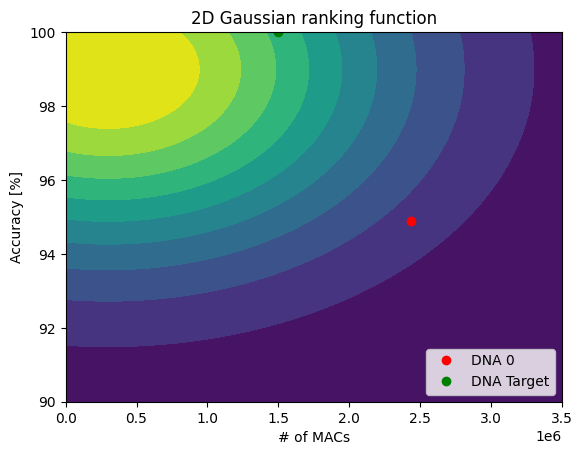

In [5]:
%run -m plot_rank_func 2440000 94.9 1500000 100

A better setting in this case would be

     mu_acc    = 100 
     sigma_acc = 4.5 
     mu_mac    = 1.5*10**6 
     sigma_mac = 1.0*10**6 


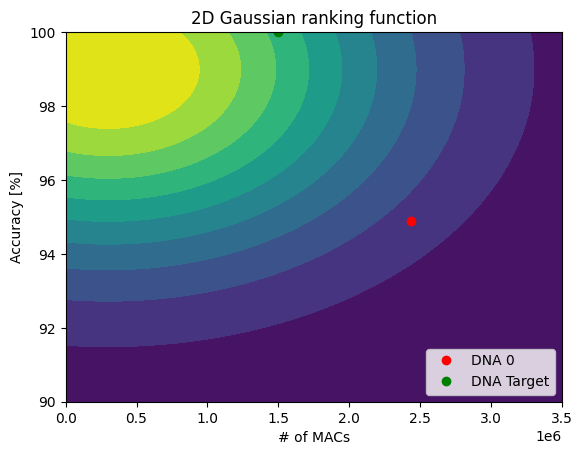

In [6]:
%run -m plot_rank_func 2440000 94.9 1500000 100

### Running EAS

If all configuration parameters have been fixed, we can start an EAS run. During training of the initial population the estimated overall runtime should be observed. A run can be interrupted at any time without loosing results generated so far.

**Limitation:**
Currently it is not possible to restart an interrupted EAS run with a previously generated population.

**Workaround**
The current state of an active EAS run, can always be observed by looking at the generated log-Files or running the analysis schripts (see below) in a different thread (e.g. on the terminal).

In [ ]:
%run -m main_evo

### Result Analysis

To get an overview of the generated architectures, we can run the following command, which will show at most 5 DNAs that were found in 3 three categories. The third category lists networks with at least 94 % accuracy. 

In [4]:
%run -m run_analysis 5 0.94

------------------------------------------------------------------------------
Best networks by accuracy only:
1: DNA 0: Acc=0.7906666398048401 with 0 MACs and 0 parameters, Generation 0 with 0 mutations
2: DNA 10: Acc=0.7049999833106995 with 3123456 MACs and 306602 parameters, Generation 1 with 1 mutations
3: DNA 13: Acc=0.6940000057220459 with 3123456 MACs and 306602 parameters, Generation 1 with 2 mutations
4: DNA 1: Acc=0.6809999942779541 with 3123456 MACs and 306602 parameters, Generation 0 with 1 mutations
5: DNA 12: Acc=0.6673333048820496 with 3123456 MACs and 306474 parameters, Generation 1 with 2 mutations
------------------------------------------------------------------------------
Best networks by number of MACs only:
DNA 0: Acc=0.7906666398048401 with 0 MACs and 0 parameters, Generation 0 with 0 mutations
DNA 23: Acc=0.3823333382606506 with 613155 MACs and 190038 parameters, Generation 3 with 3 mutations
DNA 29: Acc=0.3783333301544189 with 613155 MACs and 190038 parameters

Also, we can generate an evolution plot that shows all generated DNAs within the search space which have an accuracy of at least 85 %, and assigns each generation of DNAs a dedicated color code: 

In [5]:
%run -m plot_acc_macs 1 0.85

Total # of DNAs created: 34


In the generated Accuracy/MACs-plot we can select any DNA (hover mouse over color point) and visualize its architecture (here DNA 4):

In [6]:
%run -m visualize_cnn_arch 4

Visualizing DNA ID: 4
Found DNA ID 4


### Testset Accuracy & Retraining

Evaluate the selected DNA (here 4) on the testset and then enter "yes" to perform retraining.

In [7]:
%run -m evaluate_model best_model_dna_1

Evaluating model: best_model_dna_1
Model: "sequential_87"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_519 (Conv2D)         (None, 32, 32, 32)        896       
                                                                 
 activation_608 (Activation)  (None, 32, 32, 32)       0         
                                                                 
 batch_normalization_511 (Ba  (None, 32, 32, 32)       128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_261 (MaxPooli  (None, 7, 7, 32)         0         
 ng2D)                                                           
                                                                 
 conv2d_520 (Conv2D)         (None, 7, 7, 32)          9248      
                                                                 
 activation_609 (A